#Prévision de la consommation électrique (Stacked LSTM multivarié)
**Projet de fin de module — Deep Learning**

Objectif : prédire la puissance active globale (`Global_active_power`) d'un foyer
à partir de plusieurs variables, avec un **LSTM empilé à 3 couches**.
Jeu de données : *Individual Household Electric Power Consumption* (UCI).

Améliorations par rapport au notebook de départ :
- **ré-échantillonnage horaire** (le fichier brut contient ~2 millions de lignes
  à la minute : créer des séquences dessus sature la RAM) ;
- **encodage cyclique de l'heure** (`hour_sin`, `hour_cos`) décrit mais absent du
  notebook initial, ce qui porte le nombre de variables à 10 ;
- **normalisation ajustée sur l'ensemble d'entraînement uniquement** (évite la
  fuite d'information).


## 0. Imports et configuration

In [ ]:
import os, zipfile, urllib.request, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

os.makedirs("figs", exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device :", device)

SEQ_LENGTH = 24      # fenetre d'observation : 24 heures pour predire l'heure suivante
HIDDEN     = 128
NUM_LAYERS = 3
DROPOUT    = 0.3
EPOCHS     = 30
BATCH      = 64
LR         = 1e-3
SEED       = 42
np.random.seed(SEED); torch.manual_seed(SEED)

Device : cuda


## 1. Chargement des données
Téléchargement automatique depuis l'UCI ; sinon, déposer manuellement
`household_power_consumption.txt` dans le répertoire de travail.

In [ ]:
TXT = "household_power_consumption.txt"
UCI_URL = ("https://archive.ics.uci.edu/static/public/235/"
           "individual+household+electric+power+consumption.zip")

if not os.path.exists(TXT):
    try:
        print("Telechargement depuis UCI ...")
        urllib.request.urlretrieve(UCI_URL, "hpc.zip")
        with zipfile.ZipFile("hpc.zip") as z:
            z.extractall(".")
        # le zip UCI contient parfois un second zip imbrique
        if not os.path.exists(TXT):
            for f in os.listdir("."):
                if f.endswith(".zip") and f != "hpc.zip":
                    with zipfile.ZipFile(f) as z:
                        z.extractall(".")
        print("OK :", TXT)
    except Exception as e:
        print("Echec du telechargement :", e)
        print("-> Deposez manuellement household_power_consumption.txt puis relancez.")

# Le fichier est au format texte, separateur ';', valeurs manquantes notees '?'
data = pd.read_csv(TXT, sep=";", na_values=["?"], low_memory=False,
                   parse_dates={"datetime": ["Date", "Time"]},
                   dayfirst=True)
data = data.dropna().reset_index(drop=True)
data = data.set_index("datetime").sort_index()
print(f"Lignes (minute) apres nettoyage : {len(data):,}")
print(f"Periode : {data.index.min()}  ->  {data.index.max()}")

Telechargement depuis UCI ...
OK : household_power_consumption.txt
Lignes (minute) apres nettoyage : 2,049,280
Periode : 2006-12-16 17:24:00  ->  2010-11-26 21:02:00


## 2. Ré-échantillonnage horaire et feature engineering
On agrège à l'heure (moyenne), puis on ajoute des variables temporelles, dont
une **représentation cyclique de l'heure** (sinus/cosinus) que le LSTM exploite
mieux que l'heure brute.

In [ ]:
num_cols = ["Global_active_power", "Global_reactive_power", "Voltage",
            "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]
data[num_cols] = data[num_cols].astype(float)

df = data[num_cols].resample("1h").mean().dropna()

df["hour"]       = df.index.hour
df["dayofweek"]  = df.index.dayofweek
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
df["hour_sin"]   = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"]   = np.cos(2 * np.pi * df["hour"] / 24)

print(f"Lignes (horaire) : {len(df):,}")
df.head()

Lignes (horaire) : 34,168


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,dayofweek,is_weekend,hour_sin,hour_cos
datetime,,,,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,17,5,1,-0.965926,-2.588190e-01
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,18,5,1,-1.000000,-1.836970e-16
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,19,5,1,-0.965926,2.588190e-01
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,20,5,1,-0.866025,5.000000e-01
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,21,5,1,-0.707107,7.071068e-01


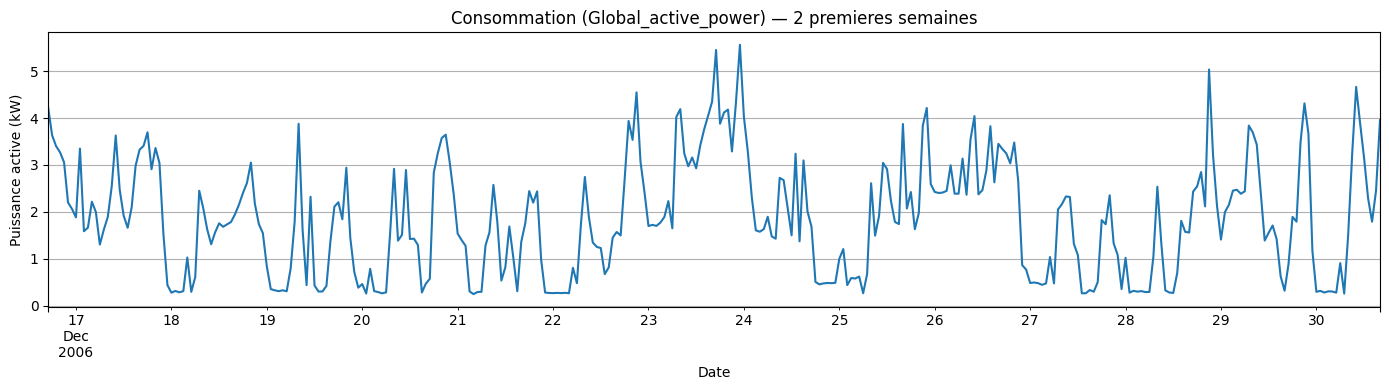

In [ ]:
# Apercu : profil de consommation sur ~2 semaines (figure : figs/tp2_overview.png)
plt.figure(figsize=(14, 4))
df["Global_active_power"].iloc[:24 * 14].plot()
plt.title("Consommation (Global_active_power) — 2 premieres semaines")
plt.xlabel("Date"); plt.ylabel("Puissance active (kW)"); plt.grid(True)
plt.tight_layout()
plt.savefig("figs/tp2_overview.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Sélection des variables, normalisation et séquences
**10 variables** (la cible en premier) :
`Global_active_power` (cible), `Global_reactive_power`, `Voltage`,
`Global_intensity`, `Sub_metering_1/2/3`, `hour_sin`, `hour_cos`, `is_weekend`.
Le `MinMaxScaler` est **ajusté sur l'entraînement uniquement**.

In [ ]:
feature_cols = ["Global_active_power", "Global_reactive_power", "Voltage",
                "Global_intensity", "Sub_metering_1", "Sub_metering_2",
                "Sub_metering_3", "hour_sin", "hour_cos", "is_weekend"]
dataset = df[feature_cols].values.astype(np.float32)
print("Forme du dataset :", dataset.shape, "(la colonne 0 est la cible)")

# split au niveau des lignes pour ajuster le scaler sans fuite
n = len(dataset)
train_rows = int(n * 0.8)

feat_scaler = MinMaxScaler().fit(dataset[:train_rows])
scaled = feat_scaler.transform(dataset).astype(np.float32)

# scaler dedie a la cible (pour revenir a l'echelle reelle en kW)
target_scaler = MinMaxScaler().fit(dataset[:train_rows, [0]])

def create_sequences(arr, seq_len):
    X, y = [], []
    for i in range(len(arr) - seq_len):
        X.append(arr[i:i + seq_len])
        y.append(arr[i + seq_len, 0])      # 0 = Global_active_power
    return np.asarray(X, np.float32), np.asarray(y, np.float32)

X, y = create_sequences(scaled, SEQ_LENGTH)
print(f"Sequences : X {X.shape} | y {y.shape}")

# split chronologique des sequences (pas de melange entre train et test)
split = int(len(X) * 0.8)
X_train, X_test = torch.from_numpy(X[:split]), torch.from_numpy(X[split:])
y_train = torch.from_numpy(y[:split]).unsqueeze(-1)
y_test  = torch.from_numpy(y[split:]).unsqueeze(-1)
print(f"Train : {X_train.shape[0]:,} | Test : {X_test.shape[0]:,}")

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=BATCH, shuffle=False)

Forme du dataset : (34168, 10) (la colonne 0 est la cible)
Sequences : X (34144, 24, 10) | y (34144,)
Train : 27,315 | Test : 6,829


## 4. Modèle Stacked LSTM (3 couches)

In [ ]:
class StackedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=3, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True,
                            dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)          # (batch, seq, hidden)
        return self.fc(out[:, -1, :])  # derniere sortie temporelle -> (batch, 1)

model = StackedLSTM(input_size=X.shape[2], hidden_size=HIDDEN,
                    num_layers=NUM_LAYERS, dropout=DROPOUT).to(device)
print(model)
print("Parametres :", sum(p.numel() for p in model.parameters()))

StackedLSTM(
  (lstm): LSTM(10, 128, num_layers=3, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
Parametres : 336001


## 5. Entraînement
Perte MSE, optimiseur Adam. On suit la perte d'entraînement et de test.

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total, n = 0.0, 0
    with torch.set_grad_enabled(train):
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            if train:
                optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, yb)
            if train:
                loss.backward()
                optimizer.step()
            total += loss.item() * Xb.size(0); n += Xb.size(0)
    return total / n

hist = {"train": [], "test": []}
t0 = time.time()
for epoch in range(EPOCHS):
    tr = run_epoch(train_loader, True)
    te = run_epoch(test_loader, False)
    hist["train"].append(tr); hist["test"].append(te)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | train MSE {tr:.5f} | test MSE {te:.5f}")
print(f"Temps total : {time.time()-t0:.1f}s")

Epoch   1/30 | train MSE 0.01260 | test MSE 0.00671
Epoch   5/30 | train MSE 0.00780 | test MSE 0.00571
Epoch  10/30 | train MSE 0.00731 | test MSE 0.00556
Epoch  15/30 | train MSE 0.00711 | test MSE 0.00537
Epoch  20/30 | train MSE 0.00684 | test MSE 0.00540
Epoch  25/30 | train MSE 0.00670 | test MSE 0.00526
Epoch  30/30 | train MSE 0.00653 | test MSE 0.00522
Temps total : 51.6s


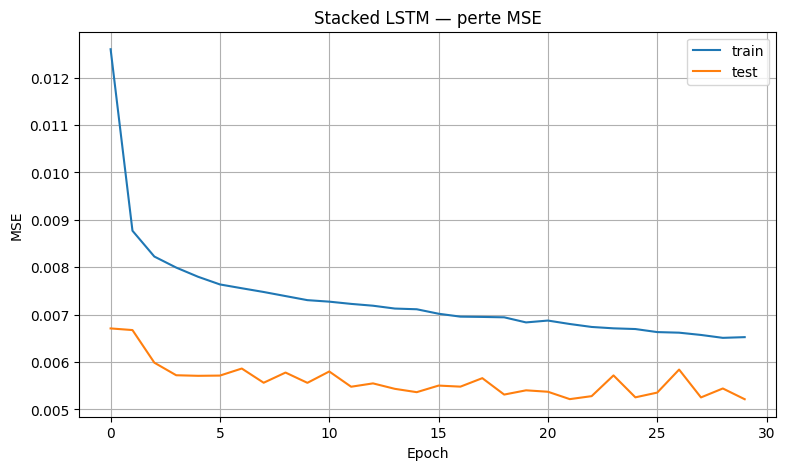

In [ ]:
# Courbe de perte (figure : figs/tp2_loss.png)
plt.figure(figsize=(9, 5))
plt.plot(hist["train"], label="train"); plt.plot(hist["test"], label="test")
plt.title("Stacked LSTM — perte MSE"); plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.legend(); plt.grid(True)
plt.savefig("figs/tp2_loss.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Prédictions et retour à l'échelle réelle

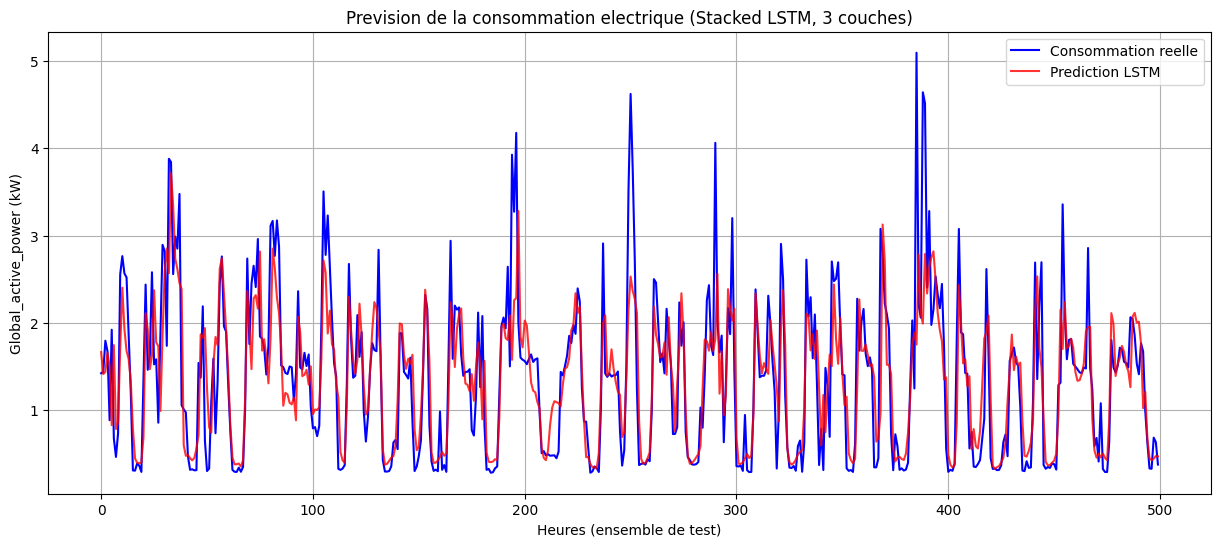

In [ ]:
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test.to(device)).cpu().numpy()

y_test_real = target_scaler.inverse_transform(y_test.numpy().reshape(-1, 1))
y_pred_real = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))

# figure : figs/tp2_pred.png (500 premiers points de test)
plt.figure(figsize=(15, 6))
plt.plot(y_test_real[:500], label="Consommation reelle", color="blue")
plt.plot(y_pred_real[:500], label="Prediction LSTM", color="red", alpha=0.8)
plt.title("Prevision de la consommation electrique (Stacked LSTM, 3 couches)")
plt.xlabel("Heures (ensemble de test)"); plt.ylabel("Global_active_power (kW)")
plt.legend(); plt.grid(True)
plt.savefig("figs/tp2_pred.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Évaluation

In [ ]:
mae  = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2   = r2_score(y_test_real, y_pred_real)
mape = np.mean(np.abs((y_test_real - y_pred_real) /
                      np.clip(np.abs(y_test_real), 1e-6, None))) * 100

print(f"MAE  : {mae:.4f} kW")
print(f"RMSE : {rmse:.4f} kW")
print(f"R2   : {r2:.4f}")
print(f"MAPE : {mape:.2f} %")

pd.DataFrame({"MAE": [mae], "RMSE": [rmse], "R2": [r2], "MAPE_%": [mape]}).to_csv(
    "figs/tp2_results.csv", index=False)

MAE  : 0.3204 kW
RMSE : 0.4649 kW
R2   : 0.6094
MAPE : 40.85 %
